In [5]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict

In [22]:
#define state
class BMIState(TypedDict):
    weigth_kg : float
    heigth_m: float
    bmi:float
    category:str

In [23]:
def calculate_bmi(state:BMIState)->BMIState:
    weigth=state['weigth_kg']
    heigth=state['heigth_m']
    bmi = weigth/(heigth**2)

    state['bmi']=round(bmi,2)
    
    return state

def label_bmi(state:BMIState)-> BMIState:
    bmi=state['bmi']
    if bmi <= 18.5:
        state['category']='UNDERWEIGTH'
    elif 18.5<bmi<= 24.9:
        state['category']='NORMAL'
    elif 24.9<bmi <= 29.9:
        state['category']='OVERWEIGTH'
    elif 29.9<bmi<= 39.9:
        state['category']='OBESE'
    else :
        state['category']='MORBIDLY OBESE' 
    return state

In [ ]:
#define Graph 
graph=StateGraph(BMIState)

# add nodes to the graph 
graph.add_node('calculate_BMI', calculate_bmi)
graph.add_node('Label_BMI', label_bmi)

# add edges to the graph 
graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', 'Label_BMI')
graph.add_edge('Label_BMI',END)


# compile the graph 
workflow=graph.compile()

In [25]:
# execute the graph 
initial_state={'weigth_kg': 85,'heigth_m':1.76}

#returns a state
final_state=workflow.invoke(initial_state)

In [26]:
final_state

{'weigth_kg': 85, 'heigth_m': 1.76, 'bmi': 27.44, 'category': 'OVERWEIGTH'}

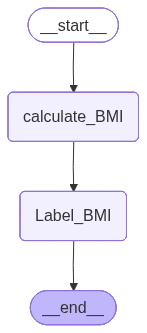

In [27]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())